# Portuguese Bank — Term Deposit Marketing Campaign Analysis
**Industry:** Banking | **Dataset:** `banking_data.csv` (45,216 records, 2008–2010)  
**Objective:** Identify factors that predict whether a client will subscribe to a term deposit.

---

## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'figure.facecolor': 'white'})
TEAL, LTEAL, ORANGE, RED = '#028090', '#A8DADC', '#F4A261', '#E63946'
PALETTE = [TEAL, LTEAL, ORANGE, RED, '#457B9D', '#1D3557']

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('DsResearch/DsResearch/Banking/banking_data.csv')
print(f'Dataset shape: {df.shape}   |   Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (45216, 19)   |   Columns: ['age', 'job', 'marital', 'marital_status', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'day_month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,marital_status,education,default,balance,housing,loan,contact,day,month,day_month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,married,tertiary,no,2143,yes,no,unknown,5,may,5-May,261,1,-1,0,unknown,no
1,44,technician,single,single,secondary,no,29,yes,no,unknown,5,may,5-May,151,1,-1,0,unknown,no
2,33,entrepreneur,married,married,secondary,no,2,yes,yes,unknown,5,may,5-May,76,1,-1,0,unknown,no
3,47,blue-collar,married,married,unknown,no,1506,yes,no,unknown,5,may,5-May,92,1,-1,0,unknown,no
4,33,unknown,single,single,unknown,no,1,no,no,unknown,5,may,5-May,198,1,-1,0,unknown,no


In [2]:
# Quick overview of data types, nulls and unique values per column
pd.DataFrame({'dtype': df.dtypes,
              'nulls': df.isnull().sum(),
              'unique': df.nunique()})

,dtype,nulls,unique
age,int64,0,77
job,str,0,12
marital,str,3,3
marital_status,str,3,3
education,str,3,4
default,str,0,2
balance,int64,0,7168
housing,str,0,2
loan,str,0,2
contact,str,0,3


---
## Q1. What is the distribution of age among the clients?

count    45216.00
mean        40.94
std         10.62
min         18.00
25%         33.00
50%         39.00
75%         48.00
max         95.00
Name: age, dtype: float64


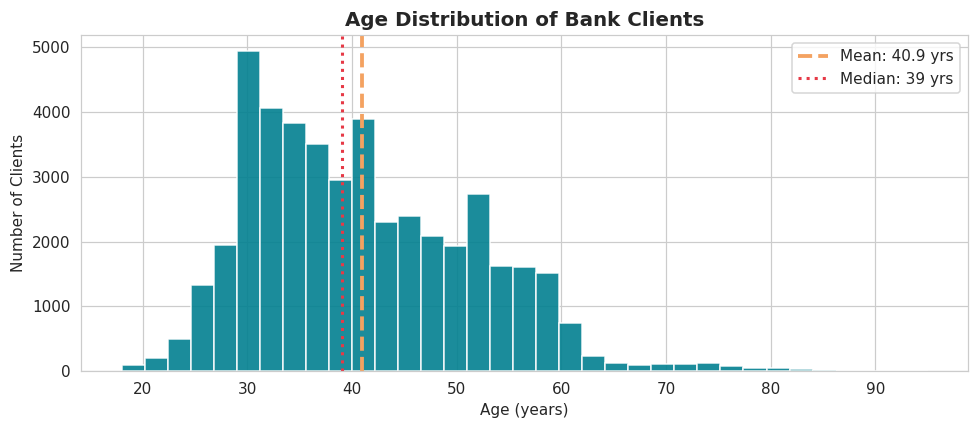

In [3]:
# Descriptive statistics for client age
print(df['age'].describe().round(2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['age'], bins=35, color=TEAL, edgecolor='white', alpha=0.9)
ax.axvline(df['age'].mean(),   color=ORANGE, lw=2.5, linestyle='--', label=f"Mean: {df['age'].mean():.1f} yrs")
ax.axvline(df['age'].median(), color=RED,    lw=2,   linestyle=':',  label=f"Median: {df['age'].median():.0f} yrs")
ax.set(xlabel='Age (years)', ylabel='Number of Clients',
       title='Age Distribution of Bank Clients')
ax.legend(); plt.tight_layout(); plt.show()
# Insight: Majority of clients are 25–55 years old; distribution is right-skewed

---
## Q2. How does job type vary among the clients?

               count   pct
job                       
blue-collar     9732  21.5
management      9460  20.9
technician      7597  16.8
admin.          5171  11.4
services        4154   9.2
retired         2267   5.0
self-employed   1579   3.5
entrepreneur    1487   3.3
unemployed      1303   2.9
housemaid       1240   2.7
student          938   2.1
unknown          288   0.6


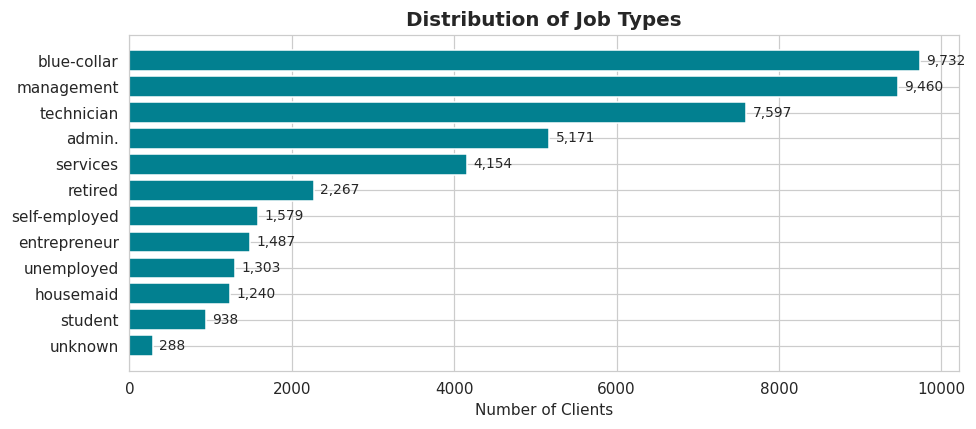

In [4]:
# Count and percentage of each job category
job_counts = df['job'].value_counts()
print(pd.DataFrame({'count': job_counts, 'pct': (job_counts/len(df)*100).round(1)}))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(job_counts.index[::-1], job_counts.values[::-1], color=TEAL)
for i, v in enumerate(job_counts.values[::-1]):
    ax.text(v + 80, i, f'{v:,}', va='center', fontsize=9)
ax.set(xlabel='Number of Clients', title='Distribution of Job Types')
plt.tight_layout(); plt.show()
# Insight: Blue-collar (21.5%) and management (20.9%) are the two largest groups

---
## Q3. What is the marital status distribution?

          count   pct
marital              
married   27216  60.2
single    12790  28.3
divorced   5207  11.5


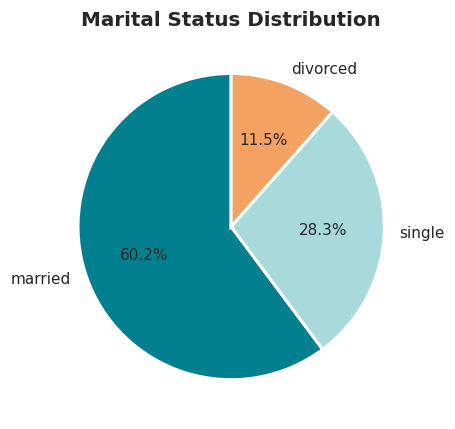

In [5]:
# Marital status breakdown
marital = df['marital'].value_counts()
print(pd.DataFrame({'count': marital, 'pct': (marital/len(df)*100).round(1)}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(marital.values, labels=marital.index, autopct='%1.1f%%',
       colors=[TEAL, LTEAL, ORANGE], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Marital Status Distribution')
plt.tight_layout(); plt.show()
# Insight: Over 60% of clients are married; single clients show higher conversion rates

---
## Q4. What is the education level among the clients?

           count   pct
education             
secondary  23204  51.3
tertiary   13301  29.4
primary     6851  15.2
unknown     1857   4.1


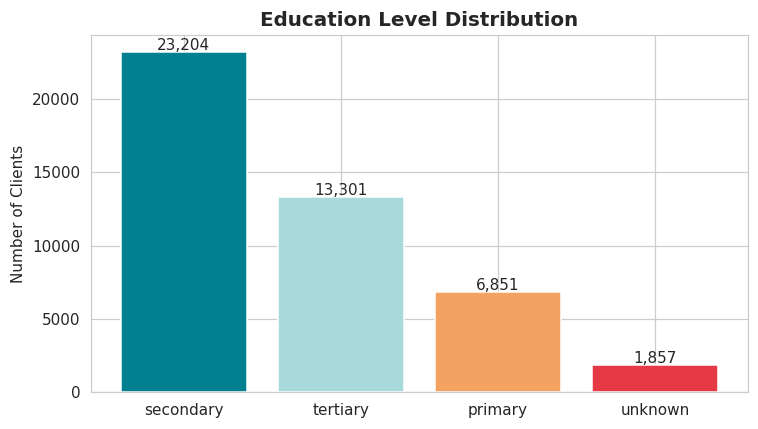

In [6]:
# Education level distribution
edu = df['education'].value_counts()
print(pd.DataFrame({'count': edu, 'pct': (edu/len(df)*100).round(1)}))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(edu.index, edu.values, color=PALETTE[:4])
for i, (k, v) in enumerate(edu.items()):
    ax.text(i, v + 150, f'{v:,}', ha='center', fontsize=10)
ax.set(ylabel='Number of Clients', title='Education Level Distribution')
plt.tight_layout(); plt.show()
# Insight: Secondary education dominates (51.3%); tertiary-educated clients convert at 15%

---
## Q5. What proportion of clients have credit in default?

In default: 815 (1.80%)
No default: 44,401 (98.20%)


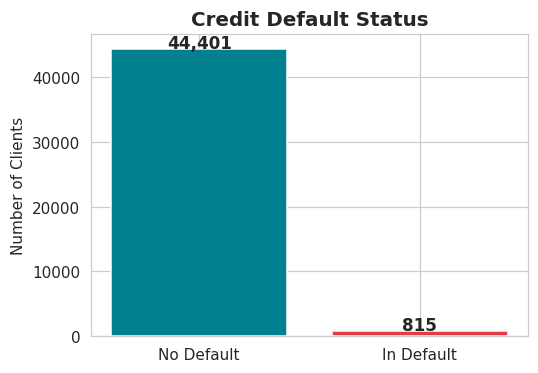

In [7]:
# Credit default status — very few clients are in default
default = df['default'].value_counts()
print(f"In default: {default['yes']:,} ({default['yes']/len(df)*100:.2f}%)")
print(f"No default: {default['no']:,} ({default['no']/len(df)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['No Default', 'In Default'], [default['no'], default['yes']], color=[TEAL, RED])
for i, v in enumerate([default['no'], default['yes']]):
    ax.text(i, v + 150, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
ax.set(ylabel='Number of Clients', title='Credit Default Status')
plt.tight_layout(); plt.show()

---
## Q6. What is the distribution of average yearly balance?

count     45216.00
mean       1362.28
std        3044.61
min       -8019.00
25%          72.00
50%         448.50
75%        1428.00
max      102127.00
Name: balance, dtype: float64


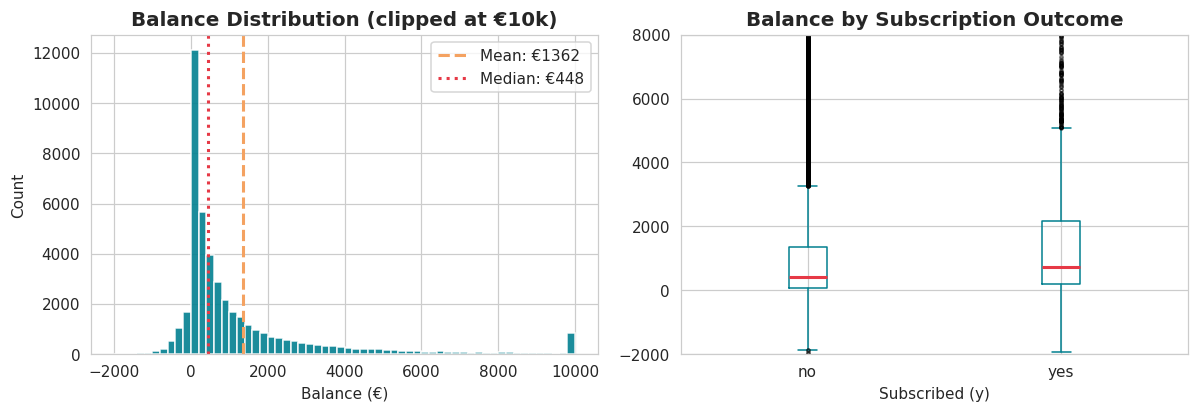

In [8]:
# Balance is highly right-skewed; median (€449) << mean (€1,362)
print(df['balance'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['balance'].clip(-2000, 10000), bins=60, color=TEAL, edgecolor='white', alpha=0.9)
axes[0].axvline(df['balance'].mean(),   color=ORANGE, lw=2, linestyle='--', label=f"Mean: €{df['balance'].mean():.0f}")
axes[0].axvline(df['balance'].median(), color=RED,    lw=2, linestyle=':',  label=f"Median: €{df['balance'].median():.0f}")
axes[0].set(xlabel='Balance (€)', ylabel='Count', title='Balance Distribution (clipped at €10k)')
axes[0].legend()

# Compare balance by subscription outcome
df.boxplot(column='balance', by='y', ax=axes[1],
           boxprops={'color': TEAL}, medianprops={'color': RED, 'lw': 2},
           whiskerprops={'color': TEAL}, capprops={'color': TEAL},
           flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
axes[1].set_ylim(-2000, 8000)
axes[1].set(xlabel='Subscribed (y)', title='Balance by Subscription Outcome')
plt.suptitle(''); plt.tight_layout(); plt.show()

---
## Q7 & Q8. How many clients have housing loans? How many have personal loans?

Housing Loan: {'yes': 25130, 'no': 20086} | Subscription rates: {'no': 16.7, 'yes': 7.7}
Personal Loan: {'no': 37972, 'yes': 7244} | Subscription rates: {'no': 12.7, 'yes': 6.7}


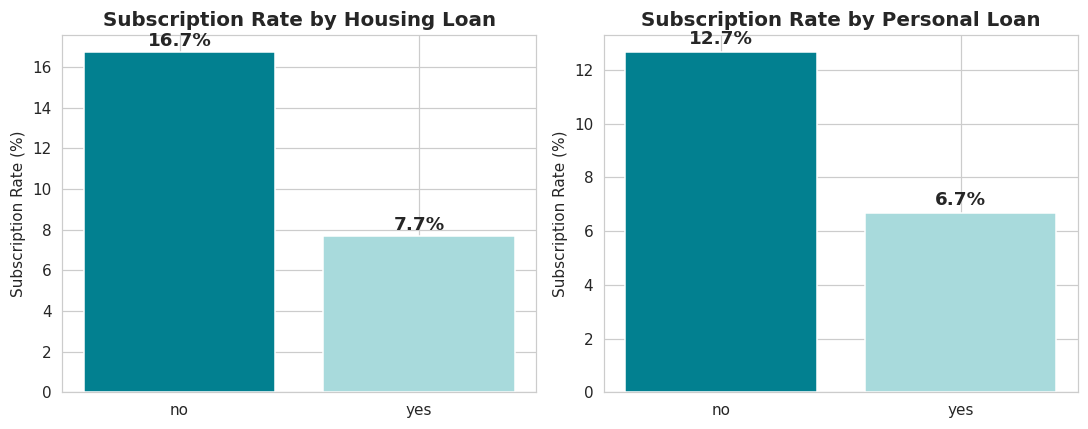

In [9]:
# Loan ownership and its impact on subscription rates
for col, label in [('housing', 'Housing Loan'), ('loan', 'Personal Loan')]:
    counts = df[col].value_counts()
    sub_rate = df.groupby(col)['y'].apply(lambda x: (x=='yes').mean()*100).round(1)
    print(f"{label}: {counts.to_dict()} | Subscription rates: {sub_rate.to_dict()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(axes, ['housing','loan'], ['Housing Loan','Personal Loan']):
    rates = df.groupby(col)['y'].apply(lambda x: (x=='yes').mean()*100)
    ax.bar(rates.index, rates.values, color=[TEAL, LTEAL])
    for i, (k, v) in enumerate(rates.items()):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
    ax.set(title=f'Subscription Rate by {title}', ylabel='Subscription Rate (%)')
plt.tight_layout(); plt.show()
# Insight: Clients WITHOUT housing loan convert at 16.7% vs only 7.7% with a housing loan

---
## Q9. What communication types were used to contact clients?

           count  sub_rate_%
contact                     
cellular   29290        14.9
telephone   2906        13.4
unknown    13020         4.1


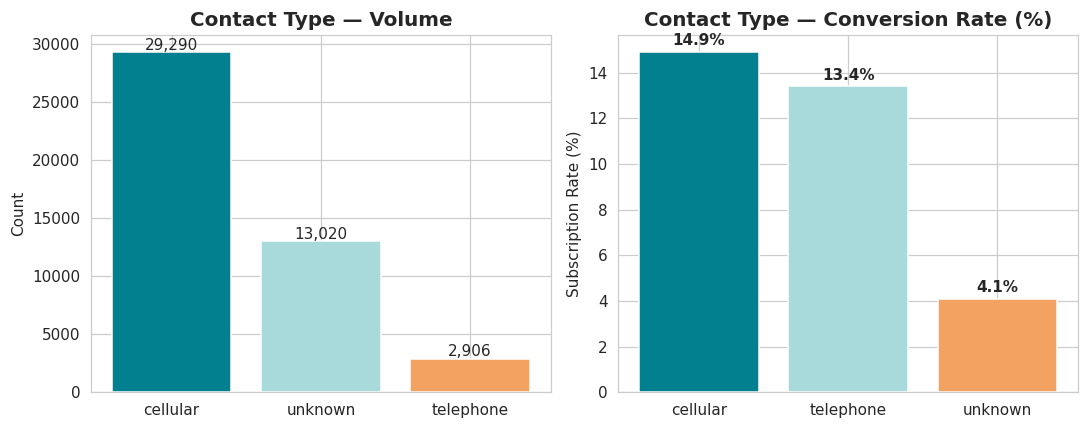

In [10]:
# Contact channel volume and conversion rates
contact = df['contact'].value_counts()
sub_contact = df.groupby('contact')['y'].apply(lambda x: (x=='yes').mean()*100).round(1)
print(pd.DataFrame({'count': contact, 'sub_rate_%': sub_contact}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(contact.index, contact.values, color=PALETTE[:3])
for i, (k, v) in enumerate(contact.items()):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
axes[0].set(title='Contact Type — Volume', ylabel='Count')
axes[1].bar(sub_contact.index, sub_contact.values, color=PALETTE[:3])
for i, (k, v) in enumerate(sub_contact.items()):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set(title='Contact Type — Conversion Rate (%)', ylabel='Subscription Rate (%)')
plt.tight_layout(); plt.show()
# Insight: Cellular contact achieves 14.9% conversion; unknown channel only 4.1%

---
## Q10. What is the distribution of the last contact day of the month?

count    45216.00
mean        15.81
std          8.32
min          1.00
25%          8.00
50%         16.00
75%         21.00
max         31.00
Name: day, dtype: float64


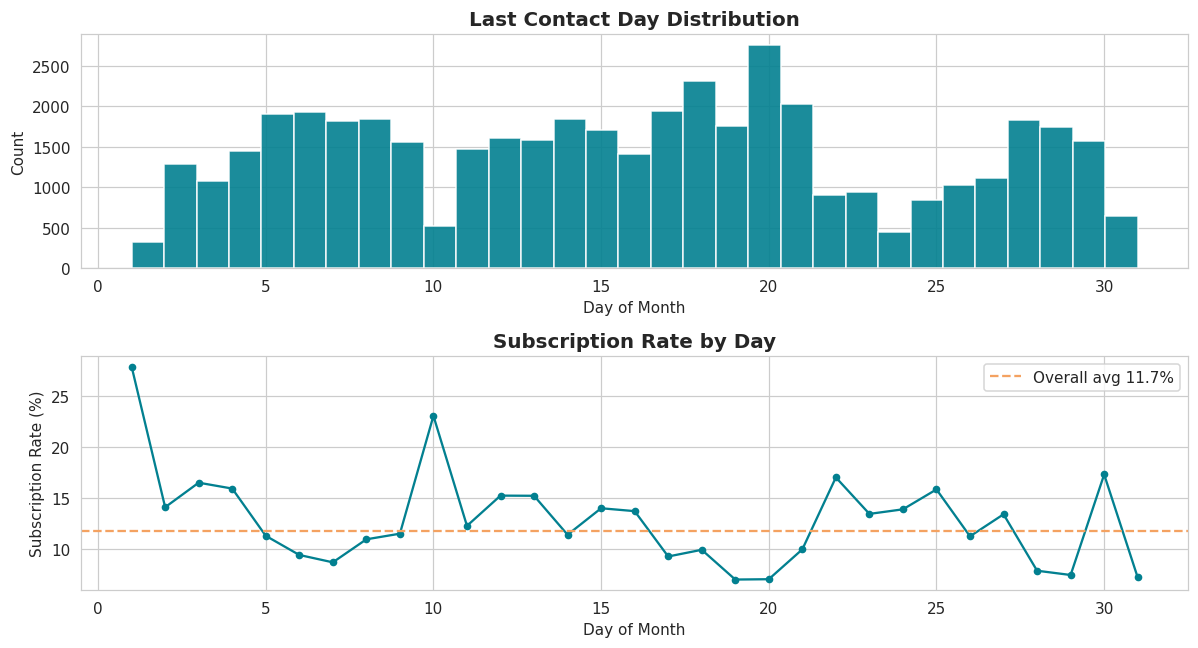

In [11]:
# Contact day distribution and subscription rate per day
print(df['day'].describe().round(2))
day_sub = df.groupby('day')['y'].apply(lambda x: (x=='yes').mean()*100)

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].hist(df['day'], bins=31, color=TEAL, edgecolor='white', alpha=0.9, range=(1, 31))
axes[0].set(xlabel='Day of Month', ylabel='Count', title='Last Contact Day Distribution')
axes[1].plot(day_sub.index, day_sub.values, color=TEAL, marker='o', ms=4)
axes[1].axhline(11.7, color=ORANGE, lw=1.5, linestyle='--', label='Overall avg 11.7%')
axes[1].set(xlabel='Day of Month', ylabel='Subscription Rate (%)', title='Subscription Rate by Day')
axes[1].legend()
plt.tight_layout(); plt.show()

---
## Q11. How does the last contact month vary among the clients?

       contacts  sub_rate_%
month                      
jan        1403        10.1
feb        2649        16.6
mar         477        52.0
apr        2932        19.7
may       13766         6.7
jun        5341        10.2
jul        6895         9.1
aug        6247        11.0
sep         579        46.5
oct         738        43.8
nov        3975        10.3
dec         214        46.7


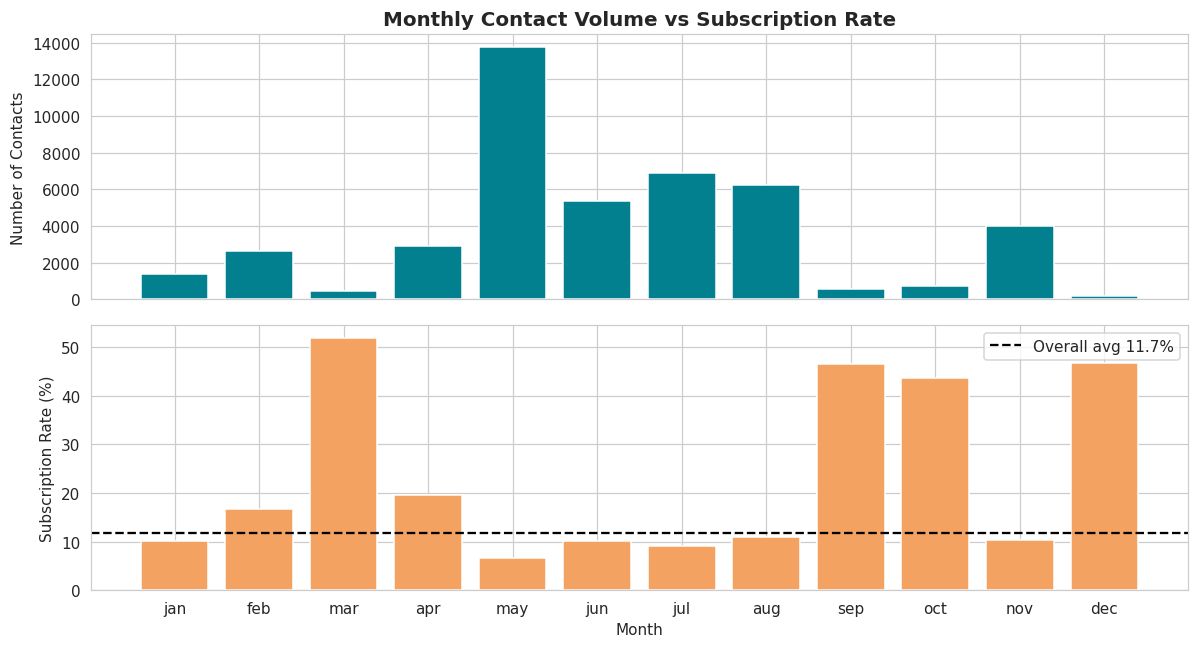

In [12]:
# Monthly contact volume vs subscription rate
month_order  = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_counts = df['month'].value_counts().reindex(month_order)
sub_month    = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean()*100).reindex(month_order)
print(pd.DataFrame({'contacts': month_counts, 'sub_rate_%': sub_month.round(1)}))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].bar(month_order, month_counts.values, color=TEAL)
axes[0].set(ylabel='Number of Contacts', title='Monthly Contact Volume vs Subscription Rate')
axes[1].bar(month_order, sub_month.values, color=ORANGE)
axes[1].axhline(11.7, color='black', lw=1.5, linestyle='--', label='Overall avg 11.7%')
axes[1].set(xlabel='Month', ylabel='Subscription Rate (%)')
axes[1].legend()
plt.tight_layout(); plt.show()
# Insight: March, Sep, Oct, Dec have 35-51% conversion despite lower call volume

---
## Q12. What is the distribution of call duration?

count    45216.00
mean       258.17
std        257.52
min          0.00
25%        103.00
50%        180.00
75%        319.00
max       4918.00
Name: duration, dtype: float64

Avg duration — subscribed:     537.1s
Avg duration — not subscribed: 221.2s


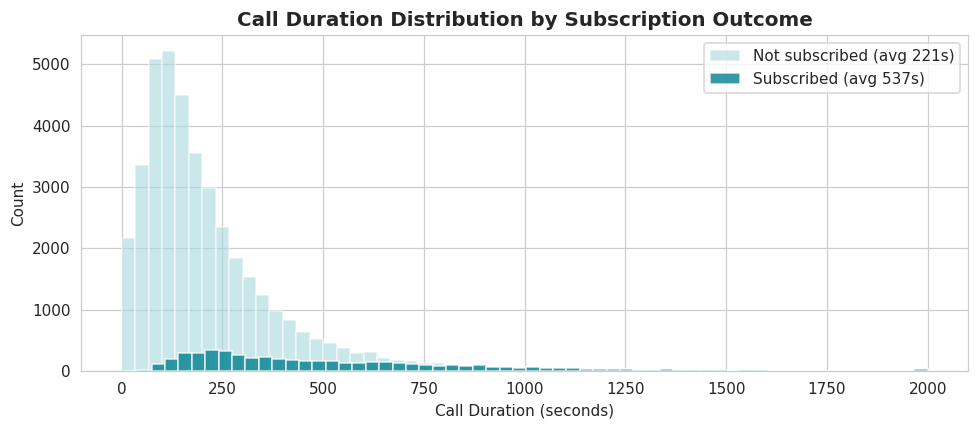

In [13]:
# Call duration is the strongest predictor of subscription (correlation = 0.394)
print(df['duration'].describe().round(2))
print(f"\nAvg duration — subscribed:     {df[df['y']=='yes']['duration'].mean():.1f}s")
print(f"Avg duration — not subscribed: {df[df['y']=='no']['duration'].mean():.1f}s")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df[df['y']=='no']['duration'].clip(0, 2000),  bins=60, alpha=0.6, color=LTEAL, label='Not subscribed (avg 221s)')
ax.hist(df[df['y']=='yes']['duration'].clip(0, 2000), bins=60, alpha=0.8, color=TEAL,  label='Subscribed (avg 537s)')
ax.set(xlabel='Call Duration (seconds)', ylabel='Count',
       title='Call Duration Distribution by Subscription Outcome')
ax.legend()
plt.tight_layout(); plt.show()

---
## Q13. How many contacts were performed during the campaign for each client?

count    45216.00
mean         2.76
std          3.10
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         63.00
Name: campaign, dtype: float64


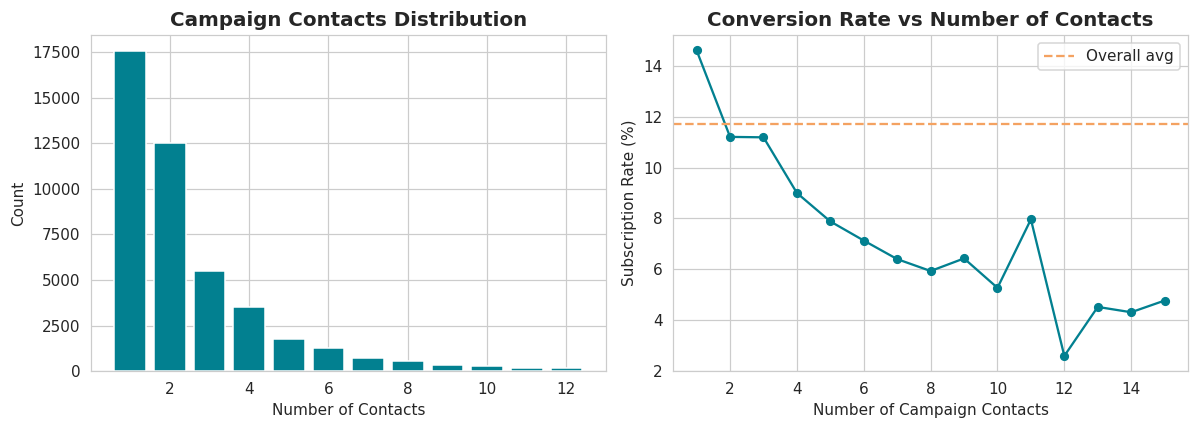

In [14]:
# More campaign calls beyond 2-3 actually reduces conversion (negative correlation)
print(df['campaign'].describe().round(2))
sub_campaign = df.groupby('campaign')['y'].apply(lambda x: (x=='yes').mean()*100)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
vc = df['campaign'].value_counts().head(12)
axes[0].bar(vc.index, vc.values, color=TEAL)
axes[0].set(xlabel='Number of Contacts', ylabel='Count', title='Campaign Contacts Distribution')
axes[1].plot(sub_campaign.head(15).index, sub_campaign.head(15).values, color=TEAL, marker='o', ms=5)
axes[1].axhline(11.7, color=ORANGE, lw=1.5, linestyle='--', label='Overall avg')
axes[1].set(xlabel='Number of Campaign Contacts', ylabel='Subscription Rate (%)',
            title='Conversion Rate vs Number of Contacts')
axes[1].legend()
plt.tight_layout(); plt.show()

---
## Q14. Distribution of days since the client was last contacted (pdays)

Never previously contacted: 36,956 (81.7%)
Previously contacted:       8,260 (18.3%)


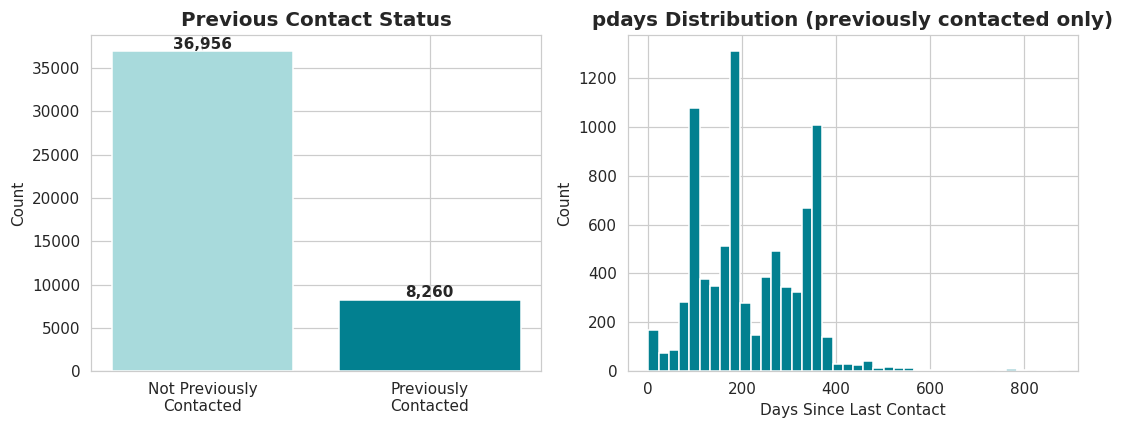

In [15]:
# pdays = -1 means the client was never previously contacted
not_contacted = (df['pdays'] == -1).sum()
contacted     = (df['pdays'] != -1).sum()
print(f"Never previously contacted: {not_contacted:,} ({not_contacted/len(df)*100:.1f}%)")
print(f"Previously contacted:       {contacted:,} ({contacted/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Not Previously\nContacted', 'Previously\nContacted'],
            [not_contacted, contacted], color=[LTEAL, TEAL])
for i, v in enumerate([not_contacted, contacted]):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')
axes[0].set(ylabel='Count', title='Previous Contact Status')
axes[1].hist(df[df['pdays'] != -1]['pdays'], bins=40, color=TEAL, edgecolor='white')
axes[1].set(xlabel='Days Since Last Contact', ylabel='Count',
            title='pdays Distribution (previously contacted only)')
plt.tight_layout(); plt.show()

---
## Q15. How many contacts were performed before the current campaign?

previous
0    36956
1     2772
2     2106
3     1142
4      715
5      459
6      278
7      205
8      130
9       92
Name: count, dtype: int64


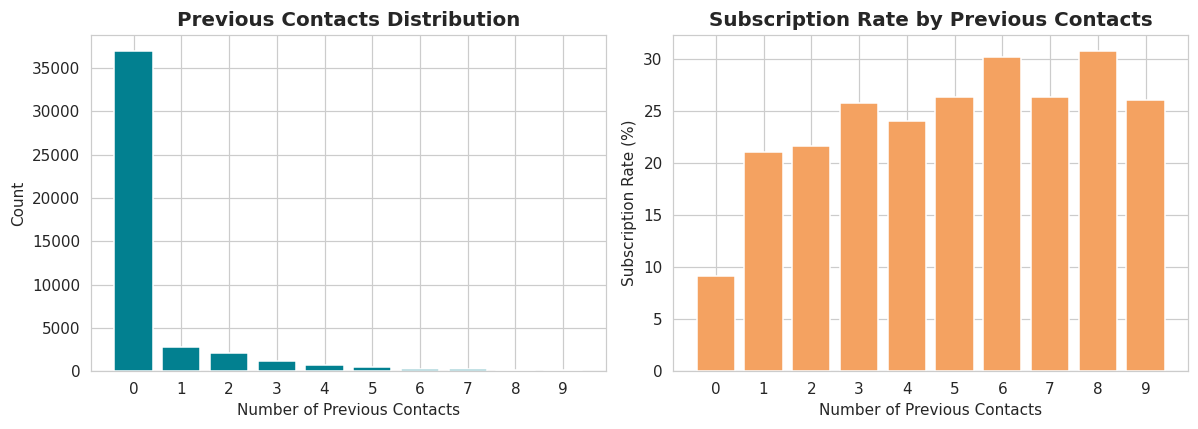

In [16]:
# More previous contacts generally improve conversion — unlike current campaign contacts
print(df['previous'].value_counts().head(10))
sub_prev = df.groupby('previous')['y'].apply(lambda x: (x=='yes').mean()*100).head(10)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
vc = df['previous'].value_counts().head(10)
axes[0].bar(vc.index.astype(str), vc.values, color=TEAL)
axes[0].set(xlabel='Number of Previous Contacts', ylabel='Count', title='Previous Contacts Distribution')
axes[1].bar(sub_prev.index.astype(str), sub_prev.values, color=ORANGE)
axes[1].set(xlabel='Number of Previous Contacts', ylabel='Subscription Rate (%)',
            title='Subscription Rate by Previous Contacts')
plt.tight_layout(); plt.show()

---
## Q16. What were the outcomes of previous marketing campaigns?

          count  sub_rate_%
poutcome                   
unknown   36961         9.2
failure    4902        12.6
other      1840        16.7
success    1513        64.8


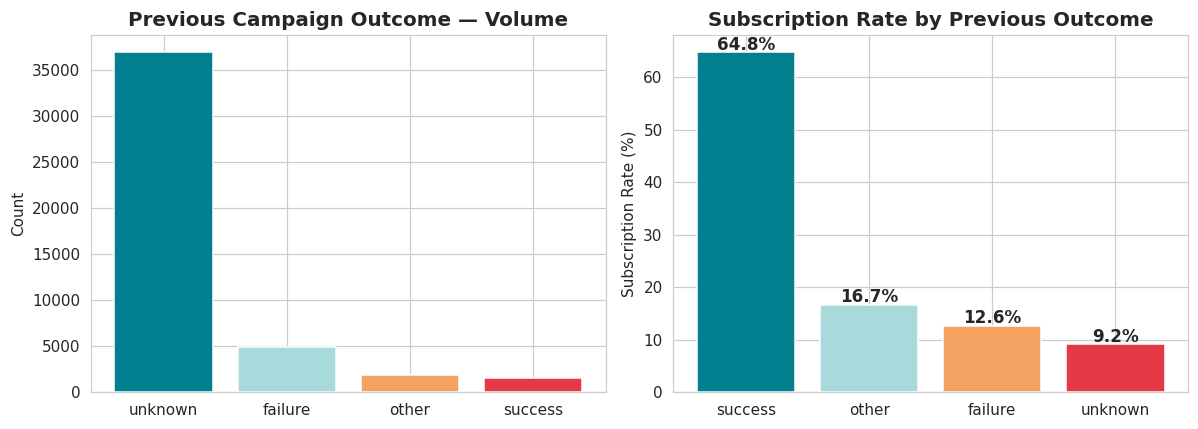

In [17]:
# Prior campaign success is the single most powerful predictor (64.8% conversion!)
pout     = df['poutcome'].value_counts()
sub_pout = df.groupby('poutcome')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
print(pd.DataFrame({'count': pout, 'sub_rate_%': sub_pout.reindex(pout.index).round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(pout.index, pout.values, color=PALETTE[:4])
axes[0].set(title='Previous Campaign Outcome — Volume', ylabel='Count')
axes[1].bar(sub_pout.index, sub_pout.values, color=PALETTE[:4])
for i, (k, v) in enumerate(sub_pout.items()):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set(title='Subscription Rate by Previous Outcome', ylabel='Subscription Rate (%)')
plt.tight_layout(); plt.show()

---
## Q17. Distribution of clients who subscribed vs. did not?

     count  pct_%
y                
no   39922  88.29
yes   5294  11.71


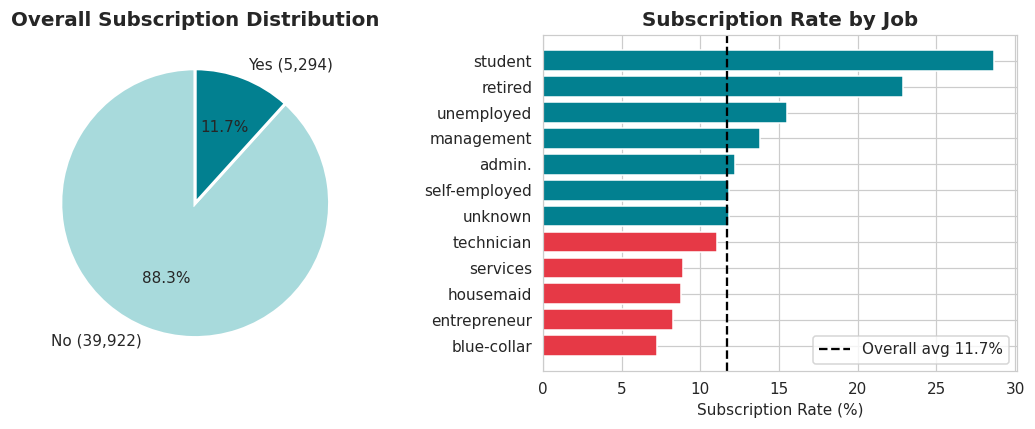

In [18]:
# Target variable — significant class imbalance (11.7% subscribed)
y_counts = df['y'].value_counts()
print(pd.DataFrame({'count': y_counts, 'pct_%': (y_counts/len(df)*100).round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].pie(y_counts.values,
            labels=[f'No ({y_counts["no"]:,})', f'Yes ({y_counts["yes"]:,})'],
            autopct='%1.1f%%', colors=[LTEAL, TEAL],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[0].set_title('Overall Subscription Distribution')

# Subscription rate by job — shows which segments convert best
sub_job = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values()
colors  = [RED if v < 11.7 else TEAL for v in sub_job.values]
axes[1].barh(sub_job.index, sub_job.values, color=colors)
axes[1].axvline(11.7, color='black', lw=1.5, linestyle='--', label='Overall avg 11.7%')
axes[1].set(xlabel='Subscription Rate (%)', title='Subscription Rate by Job')
axes[1].legend()
plt.tight_layout(); plt.show()

---
## Q18. Are there correlations between attributes and likelihood of subscribing?

Pearson correlation with subscription (y):
duration    0.3944
pdays       0.1037
previous    0.0936
balance     0.0528
age         0.0256
campaign   -0.0733
Name: y_bin, dtype: float64


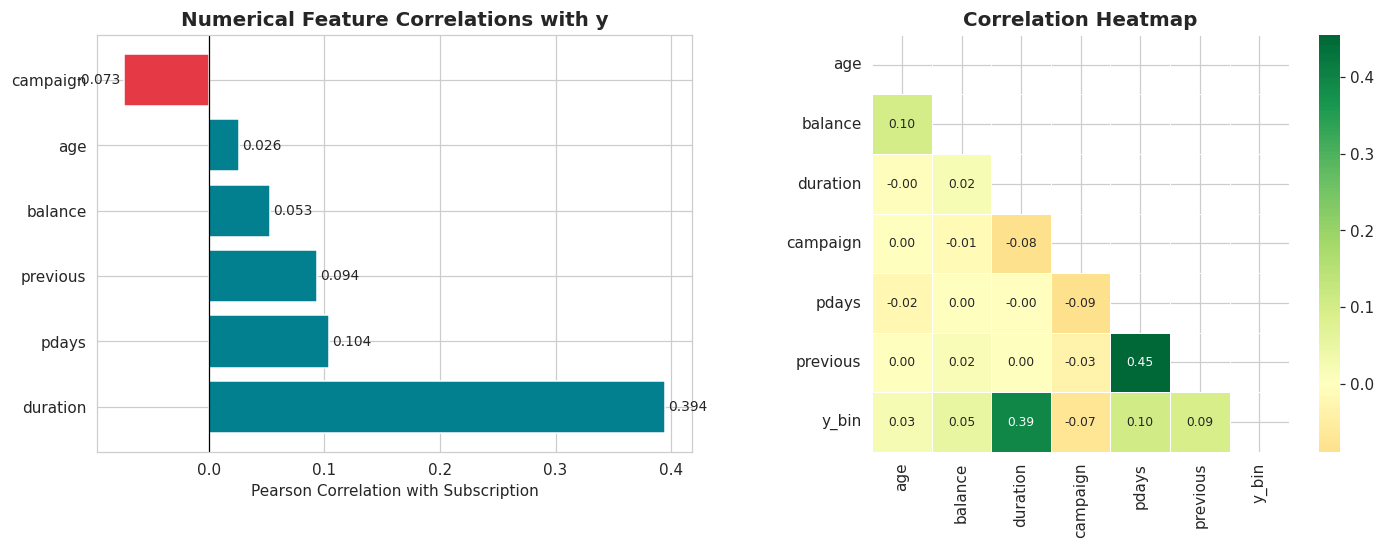

In [19]:
# Encode target as binary (1 = subscribed) for correlation analysis
df['y_bin'] = (df['y'] == 'yes').astype(int)
num_cols     = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'y_bin']
corr_matrix  = df[num_cols].corr()
y_corr       = corr_matrix['y_bin'].drop('y_bin').sort_values(ascending=False)

print('Pearson correlation with subscription (y):')
print(y_corr.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Bar chart of correlations
colors = [TEAL if v > 0 else RED for v in y_corr.values]
axes[0].barh(y_corr.index, y_corr.values, color=colors)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set(xlabel='Pearson Correlation with Subscription',
            title='Numerical Feature Correlations with y')
for i, v in enumerate(y_corr.values):
    axes[0].text(v + (0.003 if v >= 0 else -0.003), i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)
# Correlation heatmap
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[1], mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Correlation Heatmap')
plt.tight_layout(); plt.show()

In [20]:
# Subscription rates across all key categorical variables
for col in ['job', 'marital', 'education', 'contact', 'poutcome', 'housing', 'loan', 'default']:
    rates = df.groupby(col)['y_bin'].mean().mul(100).sort_values(ascending=False).round(1)
    print(f'--- {col} ---')
    print(rates.to_string(), '\n')

--- job ---
job
student          28.7
retired          22.9
unemployed       15.5
management       13.8
admin.           12.2
self-employed    11.8
unknown          11.8
technician       11.1
services          8.9
housemaid         8.8
entrepreneur      8.3
blue-collar       7.3 

--- marital ---
marital
single      15.0
divorced    12.0
married     10.1 

--- education ---
education
tertiary     15.0
unknown      13.6
secondary    10.6
primary       8.6 

--- contact ---
contact
cellular     14.9
telephone    13.4
unknown       4.1 

--- poutcome ---
poutcome
success    64.8
other      16.7
failure    12.6
unknown     9.2 

--- housing ---
housing
no     16.7
yes     7.7 

--- loan ---
loan
no     12.7
yes     6.7 

--- default ---
default
no     11.8
yes     6.4 



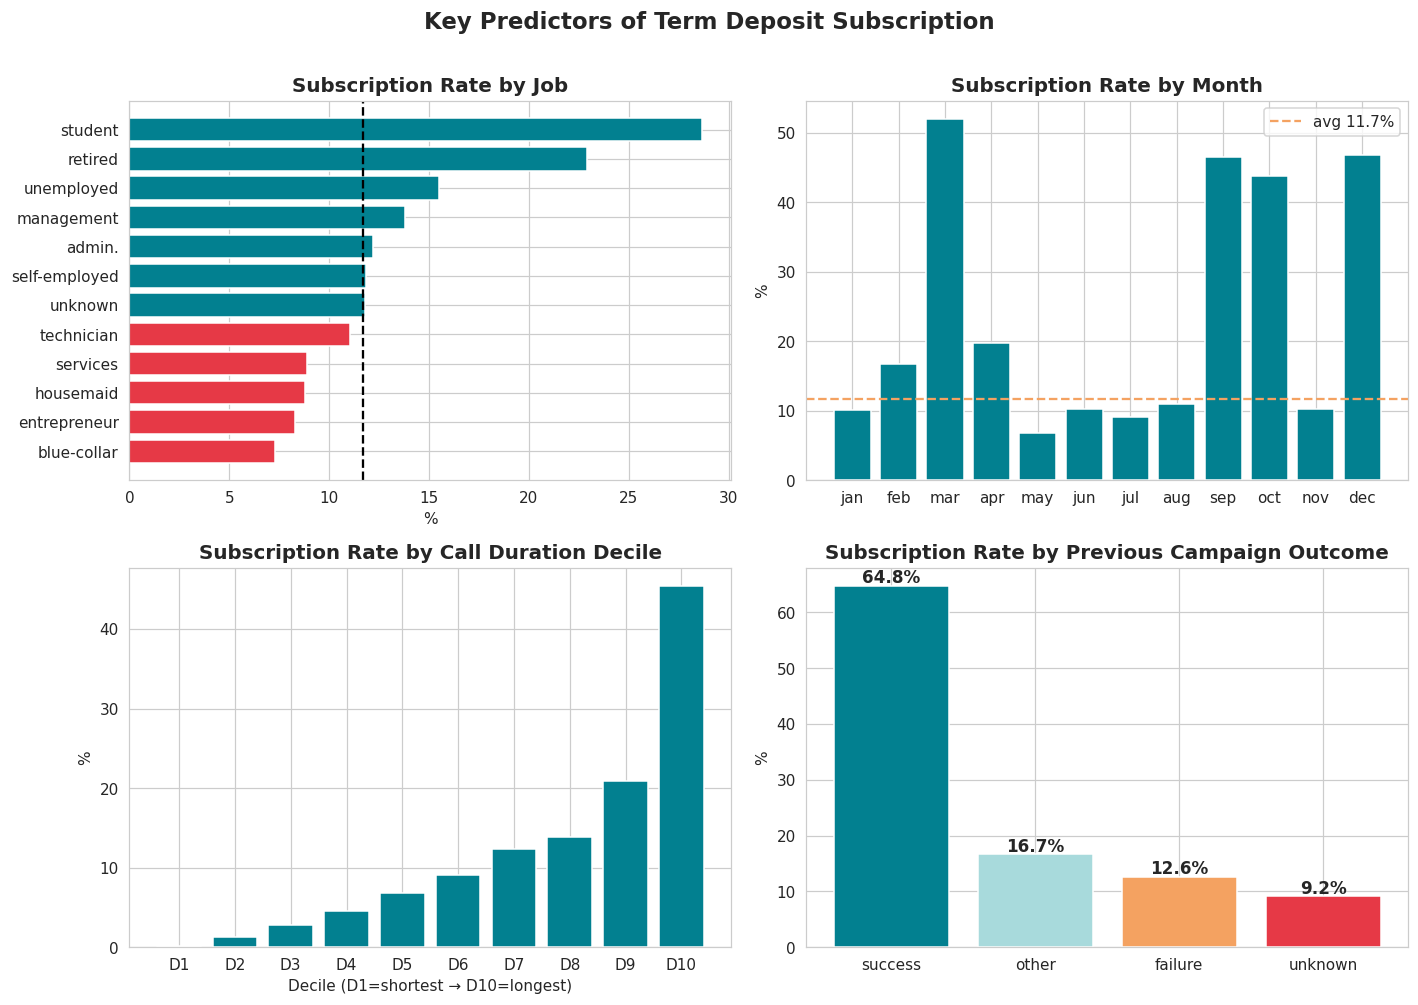

In [21]:
# Summary 4-panel chart showing the most impactful predictors
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Job subscription rates
sub_job  = df.groupby('job')['y_bin'].mean().mul(100).sort_values()
col_j    = [RED if v < 11.7 else TEAL for v in sub_job.values]
axes[0,0].barh(sub_job.index, sub_job.values, color=col_j)
axes[0,0].axvline(11.7, color='black', lw=1.5, linestyle='--')
axes[0,0].set(title='Subscription Rate by Job', xlabel='%')

# Monthly subscription rates
sub_mo = df.groupby('month')['y_bin'].mean().mul(100).reindex(month_order)
axes[0,1].bar(month_order, sub_mo.values, color=TEAL)
axes[0,1].axhline(11.7, color=ORANGE, lw=1.5, linestyle='--', label='avg 11.7%')
axes[0,1].set(title='Subscription Rate by Month', ylabel='%')
axes[0,1].legend()

# Conversion by call duration decile
df['dur_decile'] = pd.qcut(df['duration'], q=10, labels=[f'D{i}' for i in range(1, 11)])
sub_dur = df.groupby('dur_decile', observed=True)['y_bin'].mean().mul(100)
axes[1,0].bar(sub_dur.index, sub_dur.values, color=TEAL)
axes[1,0].set(title='Subscription Rate by Call Duration Decile',
              xlabel='Decile (D1=shortest → D10=longest)', ylabel='%')

# Previous campaign outcome
sub_p = df.groupby('poutcome')['y_bin'].mean().mul(100).sort_values(ascending=False)
axes[1,1].bar(sub_p.index, sub_p.values, color=PALETTE[:4])
for i, (k, v) in enumerate(sub_p.items()):
    axes[1,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1,1].set(title='Subscription Rate by Previous Campaign Outcome', ylabel='%')

plt.suptitle('Key Predictors of Term Deposit Subscription', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Summary of Key Findings

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Overall subscription rate** | Only **11.7%** subscribed — strong class imbalance |
| 2 | **Strongest numerical predictor** | Call duration (r = 0.394): subscribers averaged **537s** vs 221s |
| 3 | **Best behavioural signal** | Prior campaign success → **64.8%** conversion rate |
| 4 | **Best demographic segments** | Students (28.7%) and Retired (22.9%) |
| 5 | **Best months to campaign** | March, September, October, December (35–51% conversion) |
| 6 | **Loan holders convert less** | Housing loan: 7.7% | Personal loan: 6.7% |
| 7 | **Too many calls hurts** | Campaign contacts correlate negatively (r = −0.073) |
| 8 | **Best contact channel** | Cellular (14.9%) >> Unknown (4.1%) |

### Recommendations
1. Re-target clients with previous campaign success — highest ROI segment
2. Shift campaign budget to March, September, October, and December
3. Prioritise students and retirees in outreach
4. Use cellular as the primary contact channel
5. Cap campaign calls at 3 per client to avoid diminishing returns
6. Track call duration live — calls over 5 minutes signal strong conversion intent